In [1]:
# 멀티모달 기본 이해 - 이미지를 읽어 LLM이 설명
!pip install -U langchain langchain-core langchain-community langchain-google-genai google-genai python-dotenv
!pip install -U sentence-transformers

In [2]:
import base64
from pathlib import Path
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
import os
from dotenv import load_dotenv
load_dotenv()

vision_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

사진 설명 :

이 이미지는 아기와 함께 있는 행복한 부부의 모습을 담고 있습니다. 어머니는 아기의 뺨에 다정하게 입을 맞추고 있으며, 아기는 카메라를 응시하고 있습니다. 아버지는 미소를 지으며 아기를 안고 있는 아기띠를 지지하고 있습니다. 아기는 검은색 아기띠에 안겨 있으며, 가족 모두 편안하고 행복해 보입니다.

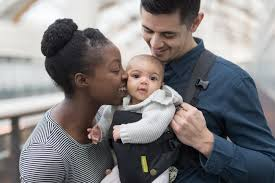

In [7]:
import base64
from pathlib import Path
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
import os
from dotenv import load_dotenv
load_dotenv()

vision_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

# 이미지를 base64 Data url(data:image/...)로 변환하는 함수
def encode_image_to_data_urlFunc(img_path:str) -> str:
  # Genimi는 Jpg는 지원하지 않음, 그래서..
  ext = Path(img_path).suffix.lower().replace(".","")

  if ext == "jpg": ext="jpeg"

  with open(img_path, "rb") as f:
    bs64 = base64.b64encode(f.read()).decode("utf-8")    # base64로 인코딩 한 뒤 문자열로 반환

  return f"data:image/{ext};base64,{bs64}"    # 랭체인이 요구하는 형식으로 반환

# 이미지를 LLM이 설명하도록 하는 함수
def desc_imageFunc(img_path:str) -> str:
  img_url = encode_image_to_data_urlFunc(img_path)
  print(img_url)

  # HumanMessage 타입 형식으로 메세지 생성
  msg = HumanMessage(
      content=[
          # LLM이 수행할 요청
          {
              "type": "text",
              "text": "현재 이미지의 보이는 내용을 5문장 이내로 설명해줘",
          },
          # 이미지 제공
          {"type": "image_url", "image_url": {"url": img_url}},
      ]
  )
  res = vision_llm.invoke([msg])
  return res.content

if __name__=="__main__":
  image_path = "person.jpeg"

  print("사진 설명 :")
  print(desc_imageFunc(image_path))
